In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Imagenes de prueba

In [2]:
img_izq = cv2.imread("inputs/cuadro_0.jpg")
img_centro = cv2.imread("inputs/cuadro_1.jpg")
img_der = cv2.imread("inputs/cuadro_2.jpg")

escala = 0.5

img_izq = cv2.resize(img_izq, None, fx=escala, fy=escala)
img_centro = cv2.resize(img_centro, None, fx=escala, fy=escala)
img_der = cv2.resize(img_der, None, fx=escala, fy=escala)

In [3]:
img_izq_rgb = cv2.cvtColor(img_izq, cv2.COLOR_BGR2RGB)
img_centro_rgb = cv2.cvtColor(img_centro, cv2.COLOR_BGR2RGB)
img_der_rgb = cv2.cvtColor(img_der, cv2.COLOR_BGR2RGB)

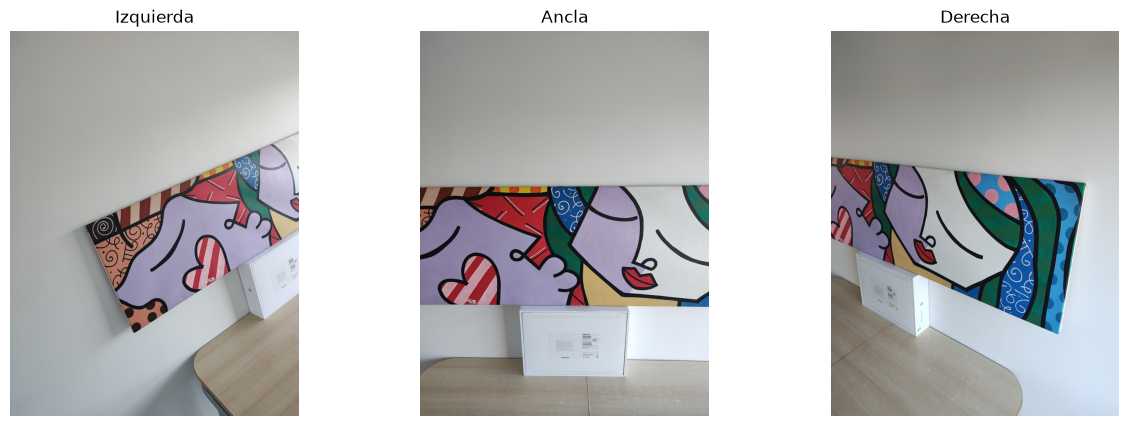

In [4]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_izq_rgb)
plt.title("Izquierda")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_centro_rgb)
plt.title("Ancla")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_der_rgb)
plt.title("Derecha")
plt.axis("off")

plt.show()

### Detección y descripción de features

Para la deteccion de features y puntos claves de las imagenes, vamos a probar diferentes tecnicas. Primero quiero ver como funcionan las funciones de openCV, como usar Fast + brief, para detectar keypoiunts y despues dar una descripcion de los punros usando brief. Pero creo que la mejor opcion va a ser usar ORB o SIFT. 

#### FAST + BRIEF

#### ORB

In [5]:
orb = cv2.ORB_create()

# Detectar keypoints y descriptores en las 3 imágenes
kp_izq, des_izq = orb.detectAndCompute(img_izq, None)
kp_centro, des_centro = orb.detectAndCompute(img_centro, None)
kp_der, des_der = orb.detectAndCompute(img_der, None)

In [6]:
img_izq_kp = cv2.drawKeypoints(
    img_izq,
    kp_izq,
    None,
    color=(0, 0, 255),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img_centro_kp = cv2.drawKeypoints(
    img_centro,
    kp_centro,
    None,
    color=(0, 0, 255),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img_der_kp = cv2.drawKeypoints(
    img_der,
    kp_der,
    None,
    color=(0, 0, 255),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

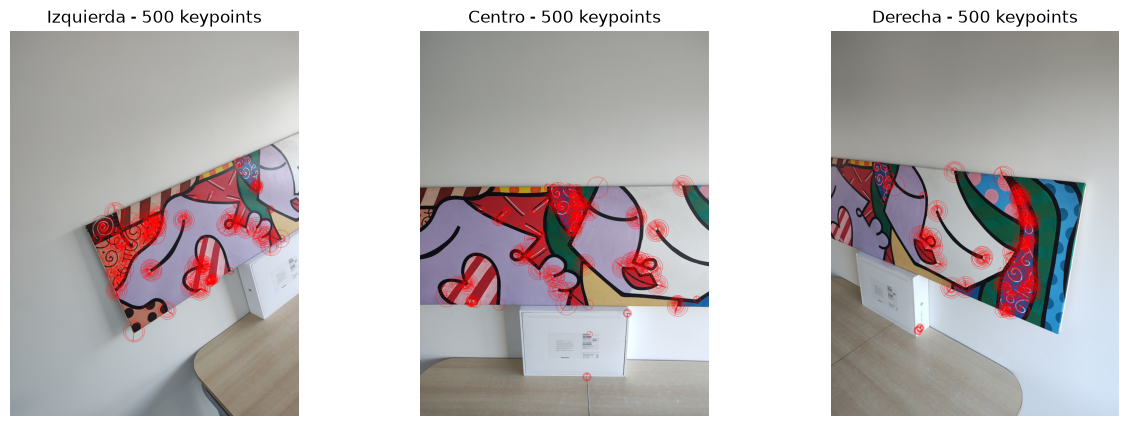

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img_izq_kp, cv2.COLOR_BGR2RGB))
plt.title(f"Izquierda - {len(kp_izq)} keypoints")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img_centro_kp, cv2.COLOR_BGR2RGB))
plt.title(f"Centro - {len(kp_centro)} keypoints")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_der_kp, cv2.COLOR_BGR2RGB))
plt.title(f"Derecha - {len(kp_der)} keypoints")
plt.axis("off")

plt.show()

#### SIFT 

In [8]:
sift = cv2.SIFT_create(nfeatures=500)

kp_izq_sift, des_izq_sift = sift.detectAndCompute(img_izq, None)
kp_centro_sift, des_centro_sift = sift.detectAndCompute(img_centro, None)
kp_der_sift, des_der_sift = sift.detectAndCompute(img_der, None)

In [9]:
img_izq_sift = cv2.drawKeypoints(
    img_izq,
    kp_izq_sift,
    None,
    color=(0, 0, 255),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img_centro_sift = cv2.drawKeypoints(
    img_centro,
    kp_centro_sift,
    None,
    color=(0, 0, 255),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img_der_sift = cv2.drawKeypoints(
    img_der,
    kp_der_sift,
    None,
    color=(0, 0, 255),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

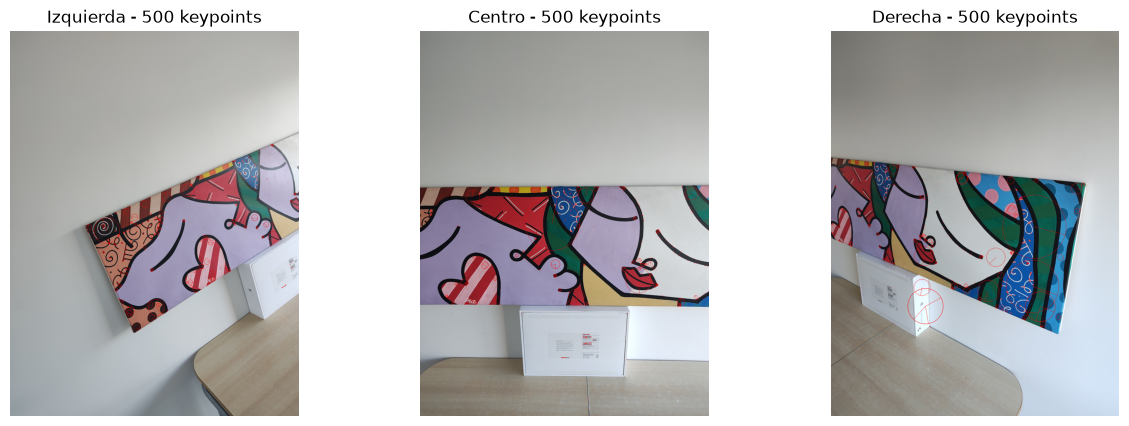

In [10]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img_izq_sift, cv2.COLOR_BGR2RGB))
plt.title(f"Izquierda - {len(kp_izq_sift)} keypoints")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img_centro_sift, cv2.COLOR_BGR2RGB))
plt.title(f"Centro - {len(kp_centro_sift)} keypoints")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_der_sift, cv2.COLOR_BGR2RGB))
plt.title(f"Derecha - {len(kp_der_sift)} keypoints")
plt.axis("off")

plt.show()

Probamos ORB y SIFT para comparar cómo detectan los puntos de interés. Los dos encuentran buenas características, pero SIFT parece distribuirlas mejor y ORB concentra más puntos en zonas con muchos detalles.

### A-NMS 

In [11]:
def anms(keypoints, descriptors, image_shape, N=150):
    h, w = image_shape[:2]

    # Radio de vecindad = 1% de la dimensión más chica
    radio_vecindad = int(0.01 * min(h, w))


    indices_locales = []

    for i, kp_i in enumerate(keypoints):
        es_maximo_local = True

        for j, kp_j in enumerate(keypoints):
            if i == j:
                continue

            dx = kp_i.pt[0] - kp_j.pt[0]
            dy = kp_i.pt[1] - kp_j.pt[1]

            distancia = np.sqrt(dx**2 + dy**2)

            if distancia < radio_vecindad and kp_j.response > kp_i.response:
                es_maximo_local = False
                break

        if es_maximo_local:
            indices_locales.append(i)

    keypoints_locales = [keypoints[i] for i in indices_locales]
    descriptors_locales = descriptors[indices_locales]


    radios = []

    for i, kp_i in enumerate(keypoints_locales):
        Ri = np.inf

        for j, kp_j in enumerate(keypoints_locales):
            if kp_j.response > kp_i.response:

                dx = kp_j.pt[0] - kp_i.pt[0]
                dy = kp_j.pt[1] - kp_i.pt[1]

                SD = dx**2 + dy**2

                if SD < Ri:
                    Ri = SD

        radios.append(Ri)


    indices_ordenados = np.argsort(radios)[::-1]

    indices_ordenados = indices_ordenados[:N]

    keypoints_finales = [
        keypoints_locales[i] for i in indices_ordenados
    ]

    descriptors_finales = descriptors_locales[indices_ordenados]

    return keypoints_finales, descriptors_finales

Lo que hicimos fue definir el radio de vecindad según el tamaño de la imagen. Así, para decidir con qué keypoints quedarnos, comparamos qué tan cerca están otros keypoints con mayor response, pero usando una distancia que se adapta a la proporción de la imagen.

A-nms con orb 

In [12]:
kp_izq_orb_anms, des_izq_orb_anms = anms(
    kp_izq, des_izq, img_izq.shape, N=150
)

kp_centro_orb_anms, des_centro_orb_anms = anms(
    kp_centro, des_centro, img_centro.shape, N=150
)

kp_der_orb_anms, des_der_orb_anms = anms(
    kp_der, des_der, img_der.shape, N=150
)

ORB antes vs después de A-NMS

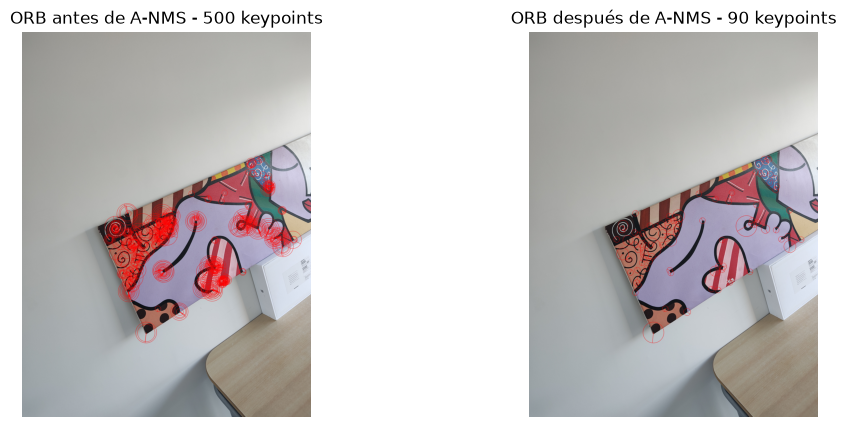

In [13]:
img_orb_antes = cv2.drawKeypoints(
    img_izq,
    kp_izq,
    None,
    color=(0, 0, 255),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img_orb_despues = cv2.drawKeypoints(
    img_izq,
    kp_izq_orb_anms,
    None,
    color=(0, 0, 255),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_orb_antes, cv2.COLOR_BGR2RGB))
plt.title(f"ORB antes de A-NMS - {len(kp_izq)} keypoints")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_orb_despues, cv2.COLOR_BGR2RGB))
plt.title(f"ORB después de A-NMS - {len(kp_izq_orb_anms)} keypoints")
plt.axis("off")

plt.show()

A-nms con sift 

In [14]:
kp_izq_sift_anms, des_izq_sift_anms = anms(
    kp_izq_sift, des_izq_sift, img_izq.shape, N=150
)

kp_centro_sift_anms, des_centro_sift_anms = anms(
    kp_centro_sift, des_centro_sift, img_centro.shape, N=150
)

kp_der_sift_anms, des_der_sift_anms = anms(
    kp_der_sift, des_der_sift, img_der.shape, N=150
)

SIFT antes vs después de A-NMS

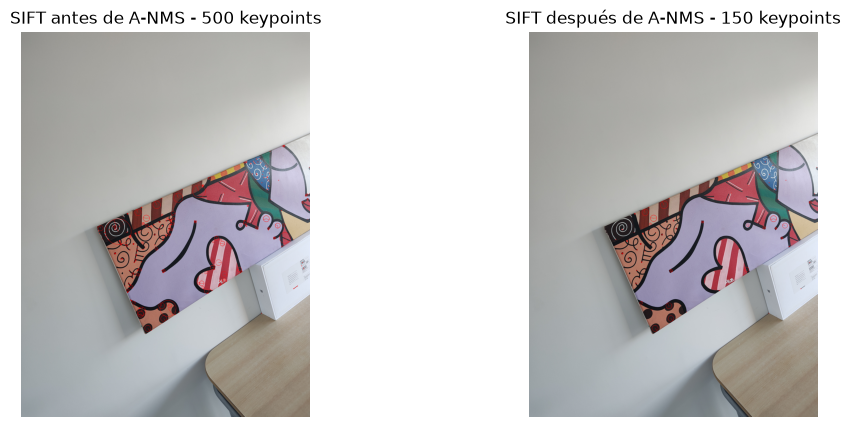

In [15]:
img_sift_antes = cv2.drawKeypoints(
    img_izq,
    kp_izq_sift,
    None,
    color=(0, 0, 255),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

img_sift_despues = cv2.drawKeypoints(
    img_izq,
    kp_izq_sift_anms,
    None,
    color=(0, 0, 255),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_sift_antes, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT antes de A-NMS - {len(kp_izq_sift)} keypoints")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_sift_despues, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT después de A-NMS - {len(kp_izq_sift_anms)} keypoints")
plt.axis("off")

plt.show()